In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [81]:
titanic = sns.load_dataset("titanic")

In [82]:
titanic.head()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [83]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [84]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [85]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [86]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [87]:
# encdoe 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [88]:
X = titanic[features]
y = titanic[target]

In [89]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Decision Tree with no Pruning

In [90]:
# decision tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [91]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.776536312849162


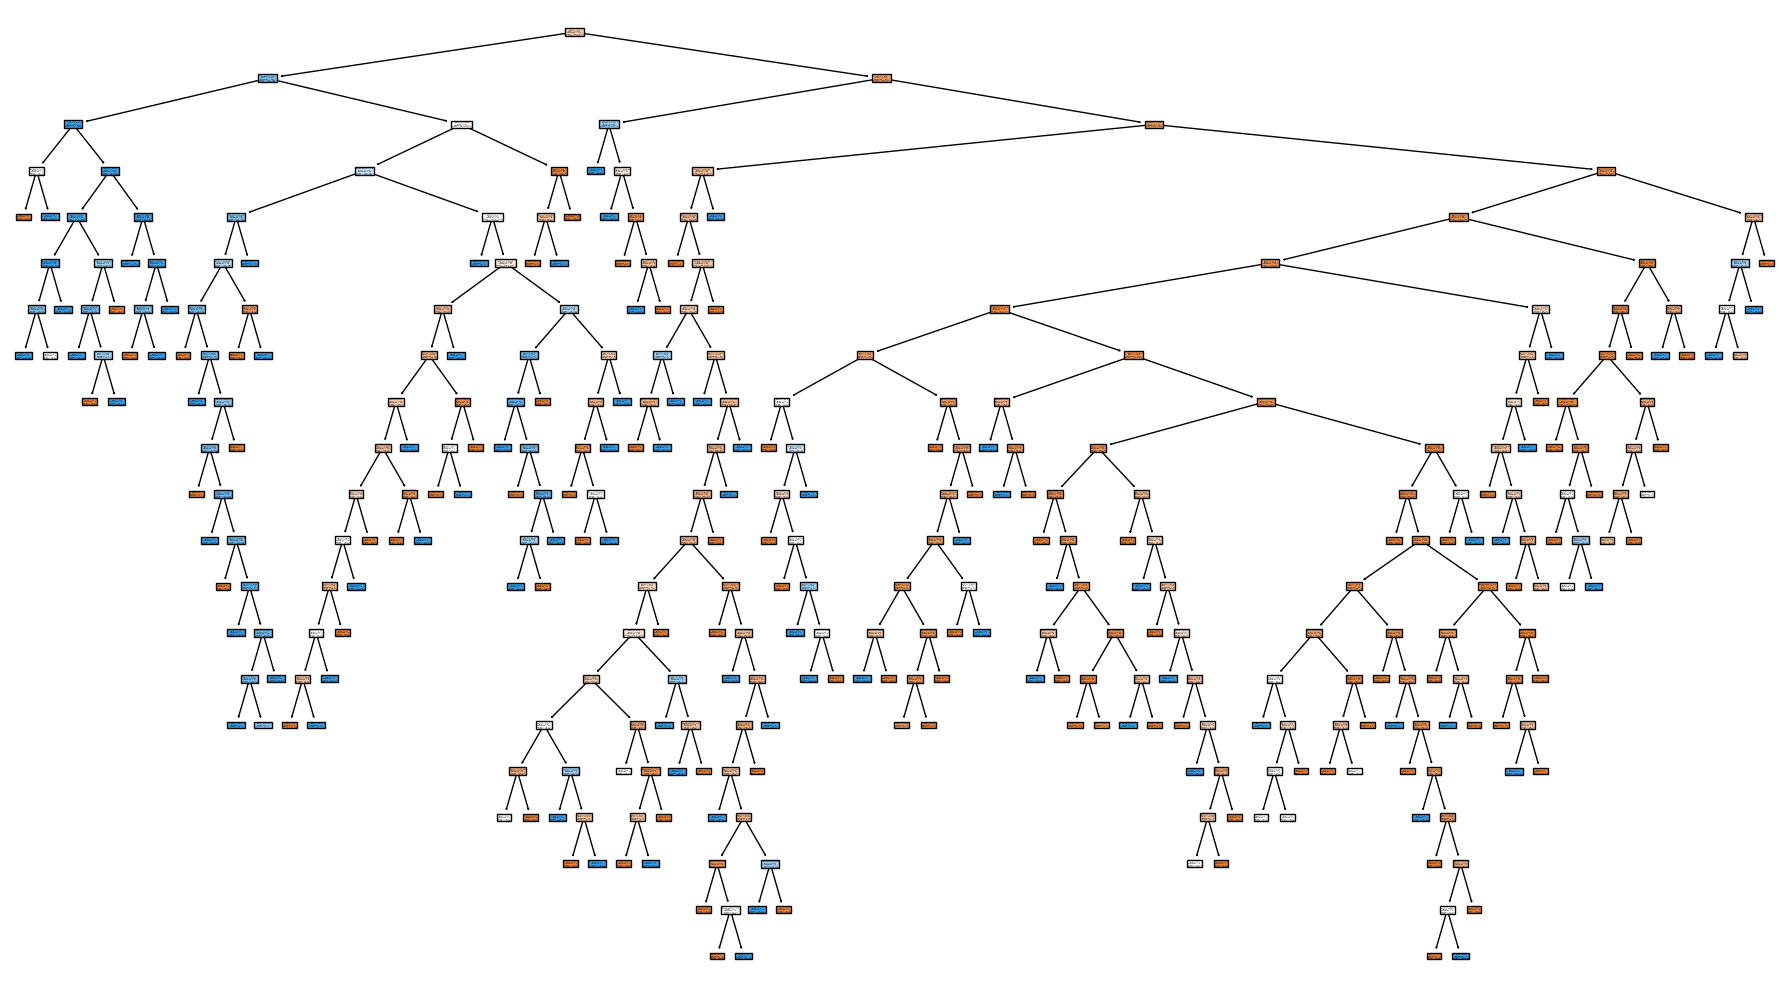

In [92]:
# plot the decision tree jo bana hai 
from sklearn.tree import plot_tree

plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

# Decision Tree with Pre-pruning

In [93]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test) # we can calculate score / accuracy directly instead of calculating y-pred then accuracy
    print(f"for depth = {depth}, accuracy = {acc}")

for depth = 2, accuracy = 0.7653631284916201
for depth = 3, accuracy = 0.7988826815642458
for depth = 4, accuracy = 0.7988826815642458
for depth = 5, accuracy = 0.7988826815642458
for depth = 6, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.8044692737430168
for depth = 8, accuracy = 0.7932960893854749
for depth = 9, accuracy = 0.7988826815642458
for depth = 10, accuracy = 0.7932960893854749


In [94]:
min_samples_split = [5,10,15,20,25,30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth = 6,min_samples_split=split)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test) # we can calculate score / accuracy directly instead of calculating y-pred then accuracy
    print(f"for sample split = {split}, accuracy = {acc}")

for sample split = 5, accuracy = 0.8044692737430168
for sample split = 10, accuracy = 0.8100558659217877
for sample split = 15, accuracy = 0.8044692737430168
for sample split = 20, accuracy = 0.8044692737430168
for sample split = 25, accuracy = 0.7988826815642458
for sample split = 30, accuracy = 0.7877094972067039


In [95]:
model = DecisionTreeClassifier(max_depth=7,min_samples_split=10)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [96]:
y_pred = model.predict(X_test)
print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.8324022346368715


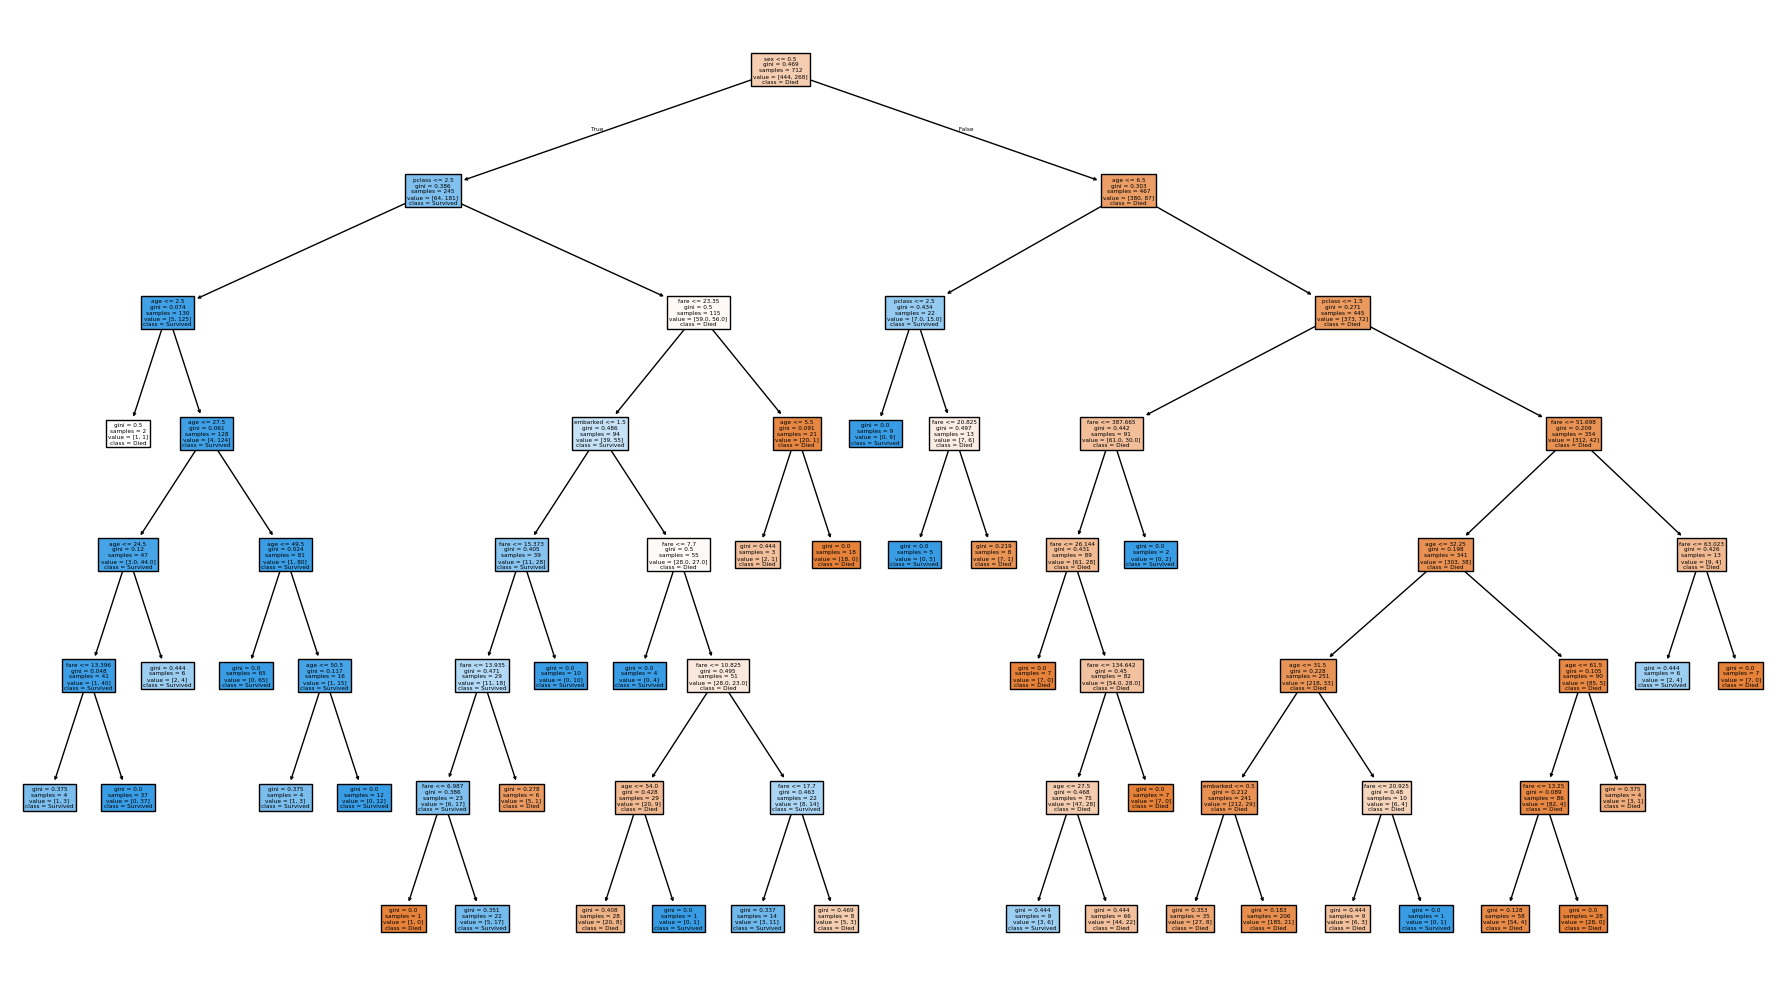

In [97]:
plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

# Decission Tree - Post-pruning

In [98]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [100]:
# train our model for all alphas

tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    tree.append((model,alpha))


In [101]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    cur_acc = model.score(X_test,y_test)
    if(cur_acc>best_acc):
        best_acc = cur_acc
        best_alpha = alpha

In [102]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


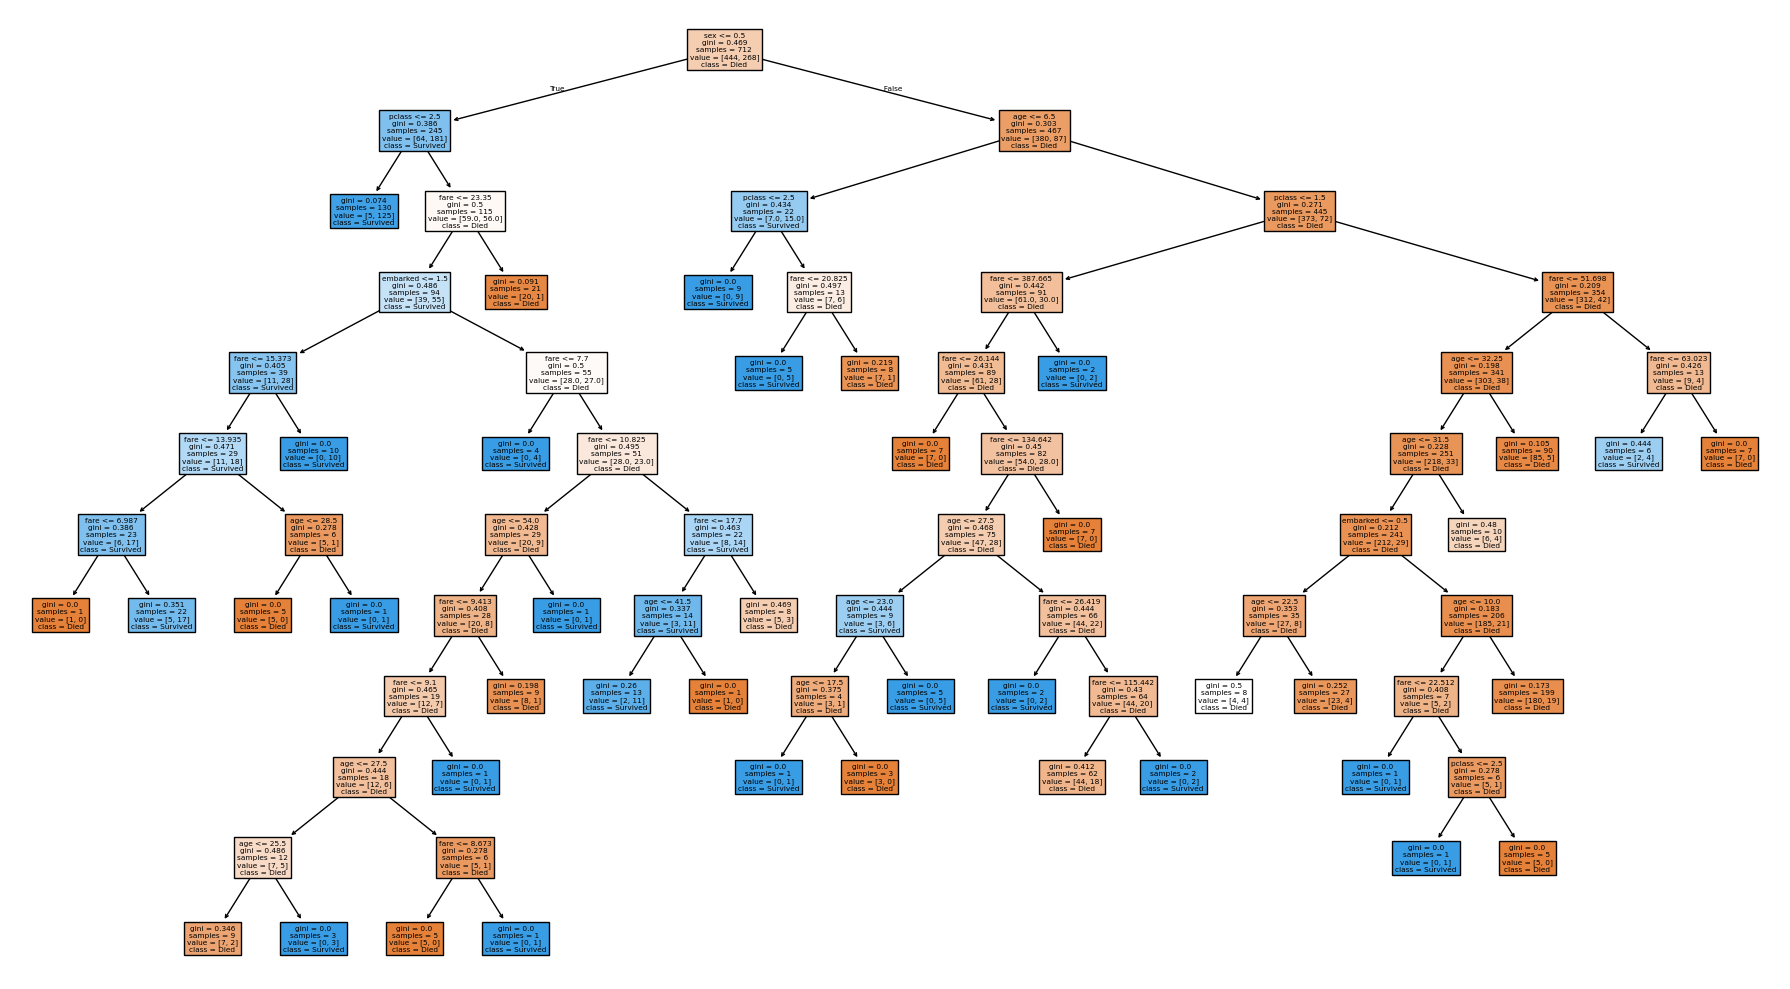

In [103]:
plt.figure(figsize = (18,10))

plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

In [104]:
print(best_model.score(X_test,y_test))

0.8379888268156425
